In [ ]:
!pip install scikit-fuzzy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 36.4 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import datetime as dt

try:
    df = pd.read_csv('/content/drive/MyDrive/MMU_SOH YI XIANG/TCI/online_retail_II.csv', encoding='ISO-8859-1')
except:
    df = pd.read_csv('/content/drive/MyDrive/MMU_SOH YI XIANG/TCI/online_retail_II.csv')

# Data Cleaning
df_clean = df.dropna(subset=['Customer ID']).copy()

df_clean = df_clean[(df_clean['Quantity'] > 0) & (df_clean['Price'] > 0)]

df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])

df_clean['TotalSpend'] = df_clean['Quantity'] * df_clean['Price']

df_clean['Customer ID'] = df_clean['Customer ID'].astype(int)

# RFM Calculation
snapshot_date = df_clean['InvoiceDate'].max() + dt.timedelta(days=1)

rfm = df_clean.groupby('Customer ID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'Invoice': 'nunique',
    'TotalSpend': 'sum'
})

rfm.rename(columns={'InvoiceDate': 'Recency',
                    'Invoice': 'Frequency',
                    'TotalSpend': 'Monetary'}, inplace=True)

print("--- RFM Data Head ---")
print(rfm.head())

--- RFM Data Head ---
             Recency  Frequency  Monetary
Customer ID                              
12346            326         12  77556.46
12347              2          8   5633.32
12348             75          5   2019.40
12349             19          4   4428.69
12350            310          1    334.40


--- Cluster Summary (Average Values) ---
            Recency  Frequency      Monetary  Count
Cluster                                            
0        384.568330   1.524946    396.999602   2305
1         37.082528  18.122677  10210.516588   1345
2        110.916966   4.074955   1389.228135   2228


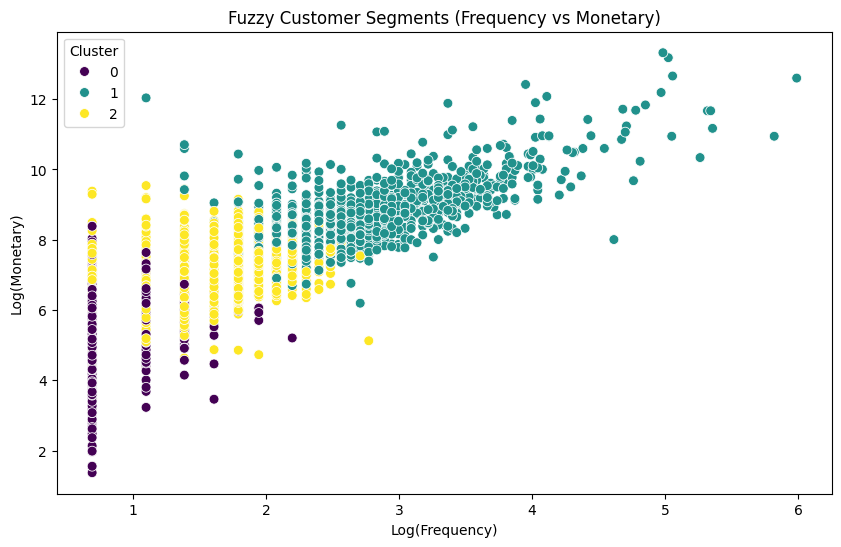


File 'rfm_fuzzy_clustered.csv' saved successfully.


In [ ]:
import numpy as np
import skfuzzy as fuzz
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns


rfm_log = np.log1p(rfm[['Recency', 'Frequency', 'Monetary']])

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log)

X = rfm_scaled.T

# Fuzzy C Means
n_centers = 3
cntr, u, u0, d, jm, p, fpc = fuzz.cluster.cmeans(
    data=X,
    c=n_centers,
    m=2.0,
    error=0.005,
    maxiter=1000,
    init=None
)

cluster_labels = np.argmax(u, axis=0)

rfm['Cluster'] = cluster_labels

for i in range(n_centers):
    rfm[f'Membership_Cluster_{i}'] = u[i]

cluster_summary = rfm.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean',
    'Membership_Cluster_0': 'count'
}).rename(columns={'Membership_Cluster_0': 'Count'})

print("--- Cluster Summary (Average Values) ---")
print(cluster_summary)

plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=np.log1p(rfm['Frequency']),
    y=np.log1p(rfm['Monetary']),
    hue=rfm['Cluster'],
    palette='viridis', s=50
)
plt.title('Fuzzy Customer Segments (Frequency vs Monetary)')
plt.xlabel('Log(Frequency)')
plt.ylabel('Log(Monetary)')
plt.show()

rfm.to_csv('rfm_fuzzy_clustered.csv')
print("\nFile 'rfm_fuzzy_clustered.csv' saved successfully.")

In [ ]:
import random
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Load Data
df = pd.read_csv('rfm_fuzzy_clustered.csv')

# Log Transformations
df['Log_Recency'] = np.log1p(df['Recency'])
df['Log_Frequency'] = np.log1p(df['Frequency'])
df['Log_Monetary'] = np.log1p(df['Monetary'])

# Interaction Terms
df['R_times_F'] = df['Recency'] * df['Frequency']
df['M_over_F'] = df['Monetary'] / (df['Frequency'] + 1)
df['R_plus_M'] = df['Recency'] + df['Monetary']

y = df['Cluster']

all_features = [
    'Recency', 'Frequency', 'Monetary',
    'Log_Recency', 'Log_Frequency', 'Log_Monetary',
    'R_times_F', 'M_over_F', 'R_plus_M'
]

X = df[all_features]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Genetic Algorithm

def fitness_function(chromosome):
    """
    Evaluates how good a 'Chromosome' (a selection of features) is.
    Returns the accuracy of a simple model using those features.
    """

    selected_features = [all_features[i] for i in range(len(chromosome)) if chromosome[i] == 1]

    if len(selected_features) == 0:
        return 0.0

    clf = RandomForestClassifier(n_estimators=10, random_state=42) # Fast model
    clf.fit(X_train[selected_features], y_train)

    predictions = clf.predict(X_test[selected_features])
    return accuracy_score(y_test, predictions)

def create_population(pop_size, n_genes):
    """Creates random initial population of binary strings"""
    return [[random.randint(0, 1) for _ in range(n_genes)] for _ in range(pop_size)]

def crossover(parent1, parent2):
    """Single-point crossover: swaps half the genes"""
    point = random.randint(1, len(parent1)-1)
    child1 = parent1[:point] + parent2[point:]
    child2 = parent2[:point] + parent1[point:]
    return child1, child2

def mutate(chromosome, mutation_rate=0.1):
    """Randomly flips bits (0->1 or 1->0)"""
    for i in range(len(chromosome)):
        if random.random() < mutation_rate:
            chromosome[i] = 1 - chromosome[i]
    return chromosome

print("--- Starting Genetic Algorithm ---")

# Parameters
POPULATION_SIZE = 10
GENERATIONS = 15
MUTATION_RATE = 0.1
N_GENES = len(all_features)

population = create_population(POPULATION_SIZE, N_GENES)

for generation in range(GENERATIONS):

    scores = [fitness_function(ind) for ind in population]

    best_score = max(scores)
    best_individual = population[scores.index(best_score)]

    print(f"Generation {generation+1}: Best Accuracy = {best_score:.4f}")

    sorted_pop = [x for _, x in sorted(zip(scores, population), reverse=True)]
    parents = sorted_pop[:POPULATION_SIZE//2]

    new_population = parents[:]

    while len(new_population) < POPULATION_SIZE:
        p1, p2 = random.sample(parents, 2)
        c1, c2 = crossover(p1, p2)
        new_population.append(mutate(c1, MUTATION_RATE))
        if len(new_population) < POPULATION_SIZE:
            new_population.append(mutate(c2, MUTATION_RATE))

    population = new_population

best_features_names = [all_features[i] for i in range(N_GENES) if best_individual[i] == 1]

print("\n--- Evolution Complete ---")
print(f"Best Features Selected: {best_features_names}")
print(f"Final Accuracy: {max(scores):.4f}")

selected_cols = best_features_names + ['Cluster']
df[selected_cols].to_csv('final_dataset_for_ann.csv', index=False)
print("Saved 'final_dataset_for_ann.csv'")

--- Starting Genetic Algorithm ---
Generation 1: Best Accuracy = 0.9802
Generation 2: Best Accuracy = 0.9802
Generation 3: Best Accuracy = 0.9802
Generation 4: Best Accuracy = 0.9807
Generation 5: Best Accuracy = 0.9807
Generation 6: Best Accuracy = 0.9807
Generation 7: Best Accuracy = 0.9807
Generation 8: Best Accuracy = 0.9807
Generation 9: Best Accuracy = 0.9807
Generation 10: Best Accuracy = 0.9807
Generation 11: Best Accuracy = 0.9807
Generation 12: Best Accuracy = 0.9807
Generation 13: Best Accuracy = 0.9813
Generation 14: Best Accuracy = 0.9813
Generation 15: Best Accuracy = 0.9813

--- Evolution Complete ---
Best Features Selected: ['Recency', 'Frequency', 'Monetary', 'Log_Recency', 'Log_Frequency', 'Log_Monetary', 'R_plus_M']
Final Accuracy: 0.9813
Saved 'final_dataset_for_ann.csv'


Loaded data from Genetic Algorithm selection.

--- Starting Training ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
147/147 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.4862 - loss: 1.0026 - val_accuracy: 0.7219 - val_loss: 0.6857
Epoch 2/50
147/147 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8408 - loss: 0.5904 - val_accuracy: 0.9507 - val_loss: 0.3327
Epoch 3/50
147/147 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9683 - loss: 0.2662 - val_accuracy: 0.9668 - val_loss: 0.1561
Epoch 4/50
147/147 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9739 - loss: 0.1373 - val_accuracy: 0.9821 - val_loss: 0.1073
Epoch 5/50
147/147 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9849 - loss: 0.0925 - val_accuracy: 0.9796 - val_loss: 0.0869
Epoch 6/50
147/147 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9828 - loss: 0.0759 - val_accuracy: 0.9881 - val_loss: 0.0715
Epoch 7/50
147/147 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9871 - loss: 0.0645 - val_accuracy: 0.9813 - val_loss: 0.0654
Epoch 8/50
147/147 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9865 - loss: 0.0616 - val_accuracy: 0.

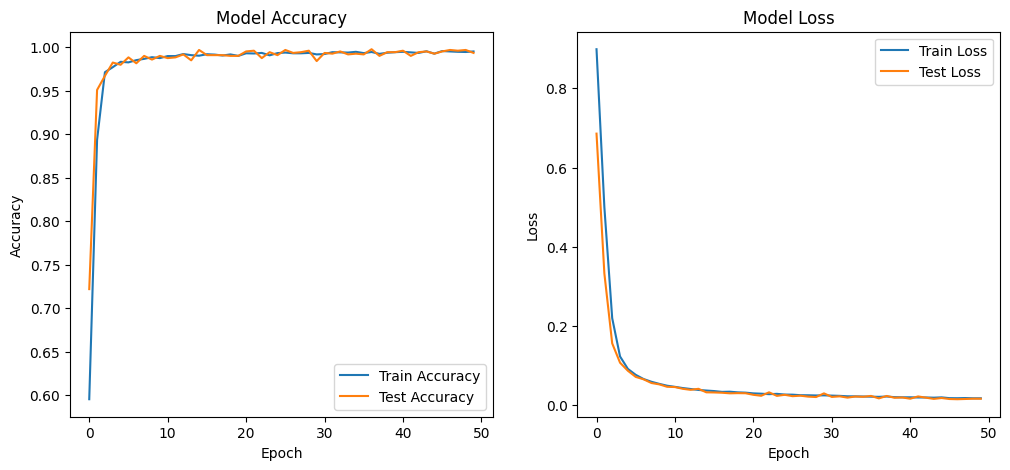

37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step

--- Confusion Matrix ---


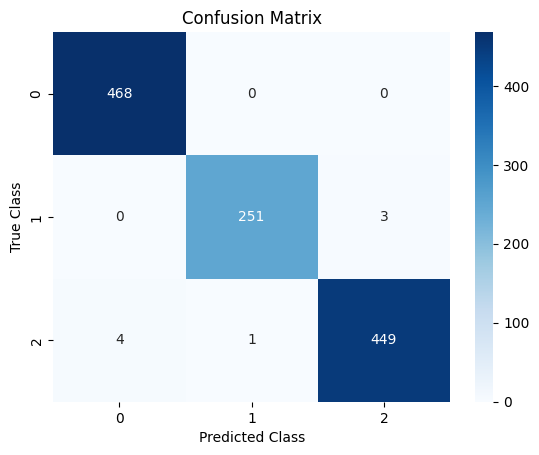


--- Classification Report ---
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       468
           1       1.00      0.99      0.99       254
           2       0.99      0.99      0.99       454

    accuracy                           0.99      1176
   macro avg       0.99      0.99      0.99      1176
weighted avg       0.99      0.99      0.99      1176



In [ ]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import classification_report, confusion_matrix


try:
    df = pd.read_csv('final_dataset_for_ann.csv')
    print("Loaded data from Genetic Algorithm selection.")
except FileNotFoundError:

    print("GA file not found. Using full Fuzzy dataset.")
    df = pd.read_csv('rfm_fuzzy_clustered.csv')

    possible_cols = ['Recency', 'Frequency', 'Monetary', 'Log_Recency', 'R_times_F']
    cols_to_use = [c for c in possible_cols if c in df.columns] + ['Cluster']
    df = df[cols_to_use]

# Separate Features (X) and Target (y)
X = df.drop('Cluster', axis=1).values
y = df['Cluster'].values

# Scale the Features (for Neural Networks)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

y_encoded = to_categorical(y)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_encoded, test_size=0.2, random_state=42)

model = Sequential()

model.add(Dense(16, input_dim=X_train.shape[1], activation='relu'))

model.add(Dense(8, activation='relu'))

model.add(Dense(3, activation='softmax'))

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

print("\n--- Starting Training ---")
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=50,
    batch_size=32,
    verbose=1
)

plt.figure(figsize=(12, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Test Accuracy')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Test Loss')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()

plt.show()

# Final Predictions
y_pred_prob = model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = np.argmax(y_test, axis=1)

# Confusion Matrix
print("\n--- Confusion Matrix ---")
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('True Class')
plt.xlabel('Predicted Class')
plt.show()

# Classification Report
print("\n--- Classification Report ---")
print(classification_report(y_true, y_pred))